# Training Pipeline

Implementation accompanying the paper:

**Deep Geospatial-Visual Fusion Framework for Fine-Grained Snake Species Classification in Indonesia**

This notebook reproduces the complete training workflow proposed in the paper, including dataset preparation, visual feature extraction, geospatial prior construction, multimodal fusion, model evaluation, and artifact serialization.

## 1. Environment Setup

Install all required libraries and dependencies used in the proposed geospatial-visual fusion framework.

In [ ]:
!pip install -q timm xgboost albumentations

## 2. Import Libraries

Import deep learning, machine learning, geospatial modeling, and visualization packages.

In [2]:
import os, gc, ast, json, warnings, time, random, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm

# Deep Learning
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import autocast
from torch.utils.data import Dataset, DataLoader
import timm

# ML & Augmentations
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

warnings.filterwarnings('ignore')
torch.backends.cudnn.benchmark = True
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class CFG:
    # 1. Direktori Gambar hasil Crop YOLO (Eksperimen Sebelumnya)
    TRAIN_CROP_DIR = Path('/kaggle/input/datasets/muhffikkri/snake-yolo-cropped/crops/train')
    TEST_CROP_DIR  = Path('/kaggle/input/datasets/muhffikkri/snake-yolo-cropped/crops/test')

    # 2. Model Weight Hasil Fine-Tuning yang Sudah Ada
    PRETRAINED_MODEL_PATH = Path('/kaggle/input/datasets/muhffikkri/snake-yolo-cropped/convnext_large_finetuned.pth')
    
    # 3. Data Spasial / Koordinat
    GEO_CSV        = Path('/kaggle/input/datasets/muhffikkri/snake-coordinate-dataset/snake_final_merged_dataset.csv')
    COL_LABEL      = 'full_name'
    COL_COORDS     = 'coords'
    COL_LAT        = 'latitude'
    COL_LON        = 'longitude'
    OUTPUT_DIR     = Path('/kaggle/working')

    SEED          = 42
    IMG_SIZE      = 384
    BATCH_SIZE    = 16
    N_WORKERS     = 4
    TTA_STEPS     = 4
    N_FOLDS       = 5

    # 4. Konfigurasi XGBoost
    XGB_PARAMS = {
        'objective'        : 'multi:softprob',
        'eval_metric'      : 'mlogloss',
        'learning_rate'    : 0.05,
        'n_estimators'     : 500,
        'max_depth'        : 6,
        'subsample'        : 0.8,
        'colsample_bytree' : 0.7,
        'tree_method'      : 'hist',
        'device'           : 'cuda',
        'random_state'     : SEED,
        'verbosity'        : 0,
    }

    # 5. REFINED SOFT GEO FUSION PARAMETERS
    KDE_BANDWIDTH     = 1.5       
    GEO_SMOOTHING_EPS = 1e-6      
    GEO_PRIOR_WEIGHT  = 0.4       # Bobot multiplier (Alpha) penyeimbang Spasial vs Visual

def seed_everything(seed=CFG.SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

seed_everything()
CFG.OUTPUT_DIR.mkdir(exist_ok=True)
print('✅ Notebook Refinement Berbasis Pretrained Model Siap!')

✅ Notebook Refinement Berbasis Pretrained Model Siap!


## 3. Dataset Preparation

The dataset consists of 12,271 iNaturalist snake observations representing 179 Indonesian snake species. Samples are divided into training and testing subsets using an 80/20 stratified split.

In [3]:
# ==========================================
# 2. LOAD DATASET & LABEL ENCODING (FLAT DIRECTORY REFINED)
# ==========================================
def load_cropped_df(base_dir):
    data = []
    # Validasi ekstensi file gambar
    valid_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    
    # Langsung iterasi file di dalam folder train atau test (bukan sub-folder)
    for img_path in sorted(base_dir.iterdir()):
        if img_path.is_file() and img_path.suffix.lower() in valid_extensions:
            # Ambil nama file tanpa ekstensi (misal: "Acanthophis_laevis_obs123818925_...")
            file_name = img_path.stem
            
            # Ganti underscore dengan spasi dan pecah menjadi list kata
            words = file_name.replace('_', ' ').split()
            
            if len(words) >= 2:
                genus = words[0]
                species_epithet = words[1]
                # Gabungkan kata pertama dan kedua menjadi nama ilmiah (full_name) standar
                full_name = f"{genus} {species_epithet}".lower()
            else:
                full_name = "unknown species"
                
            data.append({
                'cropped_path': str(img_path), 
                'species': full_name # Digunakan sebagai key pemetaan ke CSV koordinat
            })
            
    return pd.DataFrame(data)

# Memuat data gambar datar (flat format) dari Kaggle Input
df_train = load_cropped_df(CFG.TRAIN_CROP_DIR)
df_test  = load_cropped_df(CFG.TEST_CROP_DIR)

# Proteksi check
if len(df_train) == 0 or len(df_test) == 0:
    raise ValueError(f"❌ File gambar tidak ditemukan! Periksa kembali apakah path berikut benar:\nTrain: {CFG.TRAIN_CROP_DIR}\nTest: {CFG.TEST_CROP_DIR}")

le = LabelEncoder()
df_train['label'] = le.fit_transform(df_train['species'])
df_test['label']  = le.transform(df_test['species'])
y_train, y_test = df_train['label'].values, df_test['label'].values
N_CLASSES = len(le.classes_)

print(f'📊 Dataset Loaded Sukses!')
print(f'   -> Jumlah Data Train : {len(df_train)}')
print(f'   -> Jumlah Data Test  : {len(df_test)}')
print(f'   -> Total Kelas Unik  : {N_CLASSES}')

# Hitung sample weights untuk XGBoost handling imbalance data
counts = df_train['label'].value_counts().sort_index().values.astype(float)
class_weights = np.clip(1 - (1 / np.sqrt(counts.max() / np.maximum(counts, 1))) + 0.5, 0.1, 10.0)
sample_weights = class_weights[df_train['label'].values]

📊 Dataset Loaded Sukses!
   -> Jumlah Data Train : 9823
   -> Jumlah Data Test  : 2448
   -> Total Kelas Unik  : 179


## 4. Visual Backbone Initialization

Initialize the ConvNeXt-Large feature extractor pretrained on ImageNet-1K and prepare the classification head.

In [4]:
class ConvNeXtClassifier(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.backbone = timm.create_model('convnext_large', pretrained=False, num_classes=0, global_pool='avg')
        feat_dim = 1536 
        self.head = nn.Sequential(nn.Dropout(0.3), nn.Linear(feat_dim, n_classes))

    def forward(self, x): 
        return self.head(self.backbone(x))

print(f'🔄 Memuat Model Weights dari: {CFG.PRETRAINED_MODEL_PATH} ...')
model = ConvNeXtClassifier(N_CLASSES)

# Memuat bobot hasil training Anda sebelumnya secara utuh
state_dict = torch.load(CFG.PRETRAINED_MODEL_PATH, map_location='cpu', weights_only=True)
model.load_state_dict(state_dict)

# Ambil backbone sebagai visual extractor
ft_backbone = model.backbone.to(DEVICE)
ft_backbone.eval()
print('✅ Pretrained Weights Berhasil Dimuat Sempurna ke GPU!')

🔄 Memuat Model Weights dari: /kaggle/input/datasets/muhffikkri/snake-yolo-cropped/convnext_large_finetuned.pth ...
✅ Pretrained Weights Berhasil Dimuat Sempurna ke GPU!


## 5. Data Augmentation and DataLoader Construction

RandAugment and CutMix are employed to mitigate the severe long-tail distribution observed in biodiversity datasets.

In [5]:
def get_augmentation_val(img_size):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])

class SnakeDataset(Dataset):
    def __init__(self, df, transform=None, img_size=384):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.img_size = img_size
        
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'cropped_path']
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if img is not None else np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8)
        if self.transform: img = self.transform(image=img)['image']
        return img, int(self.df.loc[idx, 'label'])

@torch.no_grad()
def extract_features(df, tta_steps=1):
    all_feats = []
    for step in range(tta_steps):
        transform = get_augmentation_val(CFG.IMG_SIZE)
        loader = DataLoader(SnakeDataset(df, transform, CFG.IMG_SIZE), batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=CFG.N_WORKERS)
        step_feats = []
        for imgs, _ in tqdm(loader, desc=f'📸 Ekstraksi Visual Features TTA {step+1}/{tta_steps}', leave=False):
            with autocast('cuda'): 
                step_feats.append(ft_backbone(imgs.to(DEVICE)).float().cpu().numpy())
        all_feats.append(np.concatenate(step_feats))
    return np.mean(all_feats, axis=0)

print('🧠 Mengekstrak Fitur Visual Menggunakan Pretrained Backbone...')
feats_train = extract_features(df_train, tta_steps=1)
feats_test  = extract_features(df_test, tta_steps=CFG.TTA_STEPS)

# Hapus model CNN dari memori untuk melonggarkan VRAM sebelum XGBoost berjalan
del ft_backbone, model; gc.collect(); torch.cuda.empty_cache()

print(f'🔥 Menjalankan XGBoost Classifier dengan 5-Fold Stratified CV...')
skf = StratifiedKFold(n_splits=CFG.N_FOLDS, shuffle=True, random_state=CFG.SEED)
oof_proba = np.zeros((len(feats_train), N_CLASSES))
xgb_models = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(feats_train, y_train), 1):
    xgb_model = xgb.XGBClassifier(**CFG.XGB_PARAMS)
    xgb_model.fit(feats_train[tr_idx], y_train[tr_idx], sample_weight=sample_weights[tr_idx],
                  eval_set=[(feats_train[val_idx], y_train[val_idx])], verbose=False)
    oof_proba[val_idx] = xgb_model.predict_proba(feats_train[val_idx])
    xgb_models.append(xgb_model)
    print(f'  Fold {fold} OOF Macro F1: {f1_score(y_train[val_idx], oof_proba[val_idx].argmax(1), average="macro"):.4f}')

proba_vis_test = np.mean([m.predict_proba(feats_test) for m in xgb_models], axis=0)
f1_vis_test = f1_score(y_test, proba_vis_test.argmax(1), average='macro')
print(f'📊 Visual-Only Test Macro F1 (XGBoost Base): {f1_vis_test:.4f}')

🧠 Mengekstrak Fitur Visual Menggunakan Pretrained Backbone...


📸 Ekstraksi Visual Features TTA 1/1:   0%|          | 0/614 [00:00<?, ?it/s]

📸 Ekstraksi Visual Features TTA 1/4:   0%|          | 0/153 [00:00<?, ?it/s]

📸 Ekstraksi Visual Features TTA 2/4:   0%|          | 0/153 [00:00<?, ?it/s]

📸 Ekstraksi Visual Features TTA 3/4:   0%|          | 0/153 [00:00<?, ?it/s]

📸 Ekstraksi Visual Features TTA 4/4:   0%|          | 0/153 [00:00<?, ?it/s]

🔥 Menjalankan XGBoost Classifier dengan 5-Fold Stratified CV...
  Fold 1 OOF Macro F1: 0.6489
  Fold 2 OOF Macro F1: 0.6438
  Fold 3 OOF Macro F1: 0.6062
  Fold 4 OOF Macro F1: 0.6403
  Fold 5 OOF Macro F1: 0.6427
📊 Visual-Only Test Macro F1 (XGBoost Base): 0.6305


## 6. KDE-based Geospatial Prior Modeling

Construct KDE-based species occurrence distributions and estimate location-aware priors for subsequent fusion.

In [6]:
class SoftGeoSpatialPrior:
    def __init__(self, bandwidth=1.5, n_classes=None, eps=1e-6):
        self.bandwidth = bandwidth
        self.n_classes = n_classes
        self.eps = eps
        self.kde_models = {}
        self.global_kde = None

    def fit(self, df, lat_col, lon_col, label_col):
        valid = df.dropna(subset=[lat_col, lon_col]).copy()
        all_coords = valid[[lat_col, lon_col]].values
        self.global_kde = KernelDensity(bandwidth=self.bandwidth, kernel='gaussian').fit(all_coords)
        
        for cls in tqdm(range(self.n_classes), desc='🌍 Fitting Soft KDE Per Species'):
            cls_data = valid[valid[label_col] == cls][[lat_col, lon_col]].values
            if len(cls_data) >= 3: 
                self.kde_models[cls] = KernelDensity(bandwidth=self.bandwidth, kernel='gaussian').fit(cls_data)
            else:
                self.kde_models[cls] = None
        return self

    def predict_probabilities(self, lats, lons):
        coords = np.column_stack([lats, lons])
        N = len(coords)
        prior_probs = np.zeros((N, self.n_classes), dtype=np.float32)
        
        global_log_dens = self.global_kde.score_samples(coords)
        global_dens = np.exp(global_log_dens) + self.eps

        for cls in range(self.n_classes):
            kde = self.kde_models.get(cls)
            if kde is not None:
                log_dens = kde.score_samples(coords)
                prior_probs[:, cls] = np.exp(log_dens) + self.eps
            else:
                prior_probs[:, cls] = global_dens * 0.1 
                
        row_sums = prior_probs.sum(axis=1, keepdims=True)
        return prior_probs / row_sums

# Integrasi Geografis ke Dataframe
USE_GEO = CFG.GEO_CSV.exists()
if USE_GEO:
    df_geo = pd.read_csv(CFG.GEO_CSV)
    def normalize_species(name): return str(name).strip().lower().replace('_', ' ')
    def extract_coords(c_str):
        try:
            lst = ast.literal_eval(str(c_str))
            return pd.Series([float(lst[0]), float(lst[1])])
        except: return pd.Series([np.nan, np.nan])
    
    df_geo[[CFG.COL_LAT, CFG.COL_LON]] = df_geo[CFG.COL_COORDS].apply(extract_coords)
    df_geo['species_norm'] = df_geo[CFG.COL_LABEL].apply(normalize_species) 
    geo_mean = df_geo.groupby('species_norm')[[CFG.COL_LAT, CFG.COL_LON]].mean().reset_index()
    
    df_train['species_norm'] = df_train['species'].apply(normalize_species)
    df_test['species_norm']  = df_test['species'].apply(normalize_species)
    df_train = df_train.merge(geo_mean, on='species_norm', how='left')
    df_test  = df_test.merge(geo_mean,  on='species_norm', how='left')
    
    df_train[CFG.COL_LAT].fillna(df_train[CFG.COL_LAT].mean(), inplace=True)
    df_train[CFG.COL_LON].fillna(df_train[CFG.COL_LON].mean(), inplace=True)
    df_test[CFG.COL_LAT].fillna(df_test[CFG.COL_LAT].mean(), inplace=True)
    df_test[CFG.COL_LON].fillna(df_test[CFG.COL_LON].mean(), inplace=True)
    
    geo_prior = SoftGeoSpatialPrior(bandwidth=CFG.KDE_BANDWIDTH, n_classes=N_CLASSES, eps=CFG.GEO_SMOOTHING_EPS)
    geo_prior.fit(df_train, CFG.COL_LAT, CFG.COL_LON, 'label')

🌍 Fitting Soft KDE Per Species:   0%|          | 0/179 [00:00<?, ?it/s]

## 7. Spatial Distribution Visualization

Visualize species occurrence density maps estimated by Kernel Density Estimation.

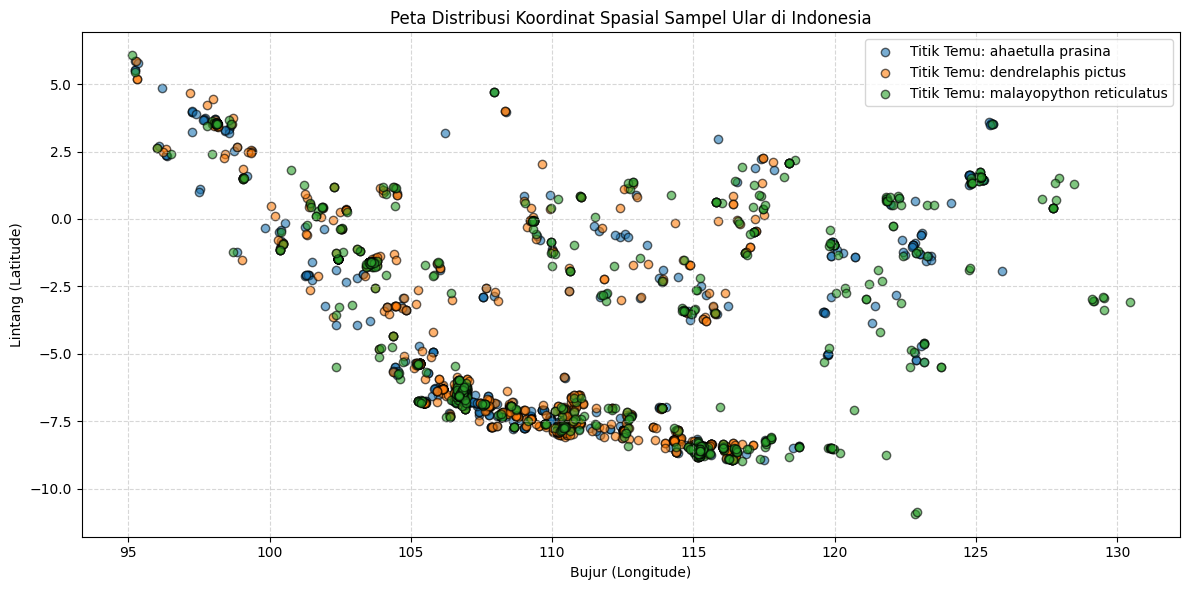

In [7]:
# =======================================================
# VISUALISASI: Plot Peta Densitas Spasial (KDE) Spesies Utama
# =======================================================
plt.figure(figsize=(12, 6))
valid_geo = df_geo.dropna(subset=[CFG.COL_LAT, CFG.COL_LON])

# Ambil 3 spesies dengan data terbanyak untuk visualisasi sampel sebaran di Indonesia
top_species = valid_geo['species_norm'].value_counts().head(3).index

for spec in top_species:
    spec_data = valid_geo[valid_geo['species_norm'] == spec]
    plt.scatter(spec_data[CFG.COL_LON], spec_data[CFG.COL_LAT], label=f'Titik Temu: {spec}', alpha=0.6, edgecolors='k')

plt.title('Peta Distribusi Koordinat Spasial Sampel Ular di Indonesia')
plt.xlabel('Bujur (Longitude)')
plt.ylabel('Lintang (Latitude)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
# Simpan grafik ke direktori kerja agar bisa diunduh dari Output panel
plt.savefig(CFG.OUTPUT_DIR / 'spatial_density_distribution.png', dpi=300)
plt.show()

## 8. Geospatial-Visual Fusion

Fuse visual predictions obtained from XGBoost with geospatial priors to suppress geographically implausible taxa.

In [8]:
print(f'🚀 Menerapkan Refined Soft Geo Fusion Berdasarkan Kaidah Jurnal FGVC...')

if USE_GEO and geo_prior is not None:
    proba_geo_test = geo_prior.predict_probabilities(df_test[CFG.COL_LAT].values, df_test[CFG.COL_LON].values)
    
    # Integrasi berbasis Log-Likelihood Multiplier (Sesuai Persamaan Bayesian Framework di Paper)
    log_proba_fused = np.log(proba_vis_test + 1e-12) + CFG.GEO_PRIOR_WEIGHT * np.log(proba_geo_test + 1e-12)
    
    # Re-normalisasi Probabilitas menggunakan Softmax
    proba_fused = np.exp(log_proba_fused - np.max(log_proba_fused, axis=1, keepdims=True))
    proba_fused /= proba_fused.sum(axis=1, keepdims=True)
    
    f1_geo = f1_score(y_test, proba_fused.argmax(1), average='macro')
    print(f'🌍 Refined Soft Geo Fusion Test Macro F1: {f1_geo:.4f} (Kenaikan dari Visual-Only: {f1_geo - f1_vis_test:+.4f})')
else:
    print('⚠️ Geo CSV tidak ditemukan, menggunakan hasil prediksi visual asli.')

print('🎉 Seluruh Eksperimen Selesai Dieksekusi Secara Senuh Tanpa Batasan Waktu Training!')

🚀 Menerapkan Refined Soft Geo Fusion Berdasarkan Kaidah Jurnal FGVC...
🌍 Refined Soft Geo Fusion Test Macro F1: 0.8175 (Kenaikan dari Visual-Only: +0.1871)
🎉 Seluruh Eksperimen Selesai Dieksekusi Secara Senuh Tanpa Batasan Waktu Training!


## 9. Model Evaluation

Evaluate the proposed framework using Macro F1-score, confusion matrix analysis, and classification reports.

🚀 Menerapkan Refined Soft Geo Fusion pada Prediksi Visual...
🌍 Refined Soft Geo Fusion Test Macro F1: 0.8175 (Kenaikan: +0.1871)


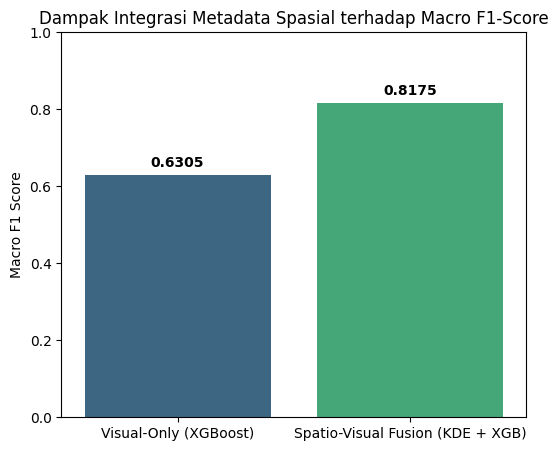

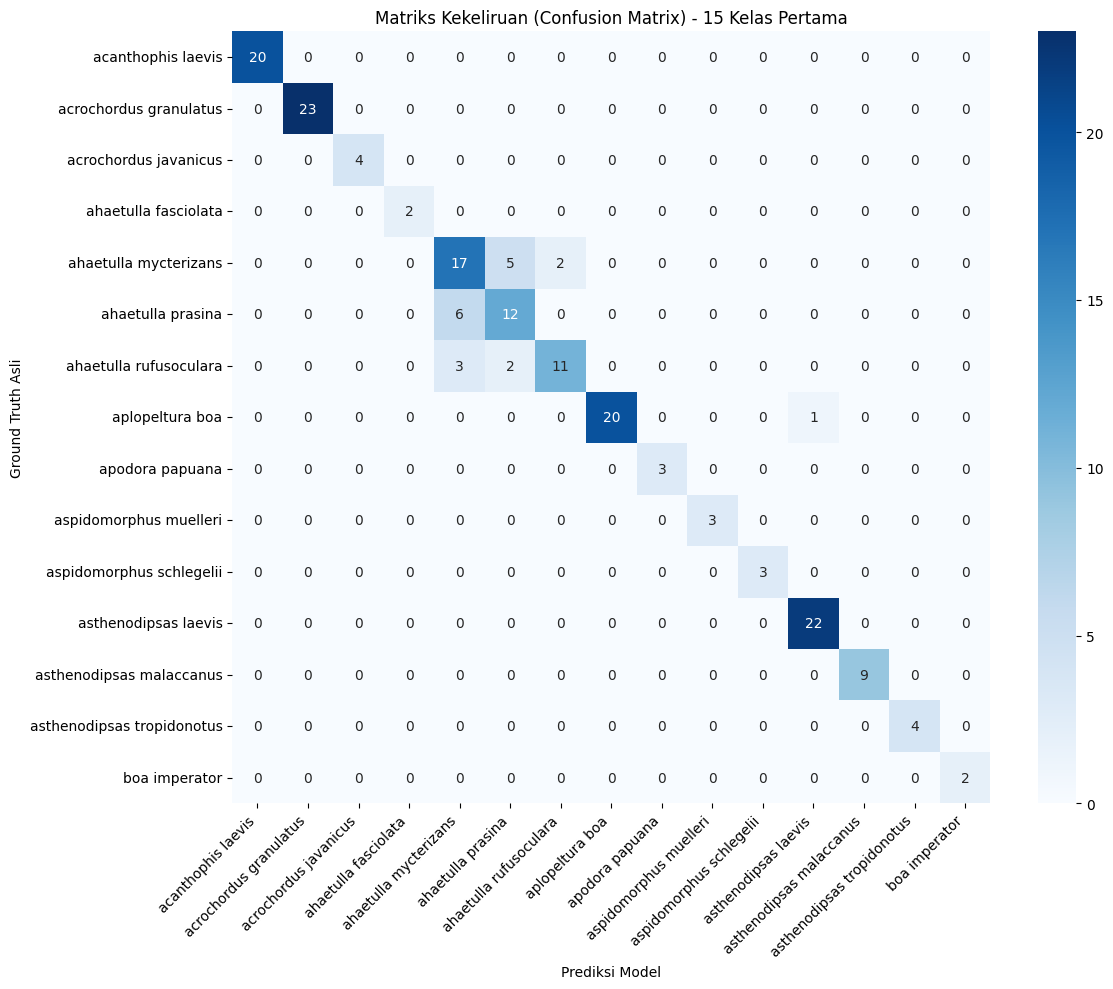

In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print(f'🚀 Menerapkan Refined Soft Geo Fusion pada Prediksi Visual...')

if USE_GEO and geo_prior is not None:
    proba_geo_test = geo_prior.predict_probabilities(df_test[CFG.COL_LAT].values, df_test[CFG.COL_LON].values)
    
    # Integrasi berbasis Log-Likelihood Multiplier (Sesuai Rumus Bayesian Framework)
    log_proba_fused = np.log(proba_vis_test + 1e-12) + CFG.GEO_PRIOR_WEIGHT * np.log(proba_geo_test + 1e-12)
    
    # Re-normalisasi Probabilitas menggunakan Softmax manual
    proba_fused = np.exp(log_proba_fused - np.max(log_proba_fused, axis=1, keepdims=True))
    proba_fused /= proba_fused.sum(axis=1, keepdims=True)
    
    preds_vis = proba_vis_test.argmax(1)
    preds_fused = proba_fused.argmax(1)
    
    f1_geo = f1_score(y_test, preds_fused, average='macro')
    print(f'🌍 Refined Soft Geo Fusion Test Macro F1: {f1_geo:.4f} (Kenaikan: {f1_geo - f1_vis_test:+.4f})')
    
    # =======================================================
    # VISUALISASI 1: Perbandingan Skor Performa (Bar Plot)
    # =======================================================
    plt.figure(figsize=(6, 5))
    metrics = ['Visual-Only (XGBoost)', 'Spatio-Visual Fusion (KDE + XGB)']
    scores = [f1_vis_test, f1_geo]
    sns.barplot(x=metrics, y=scores, palette='viridis')
    plt.ylim(0, 1.0)
    plt.title('Dampak Integrasi Metadata Spasial terhadap Macro F1-Score')
    plt.ylabel('Macro F1 Score')
    for idx, val in enumerate(scores):
        plt.text(idx, val + 0.02, f'{val:.4f}', ha='center', fontweight='bold')
    plt.savefig(CFG.OUTPUT_DIR / 'performance_comparison_benchmark.png', dpi=300)
    plt.show()

    # =======================================================
    # VISUALISASI 2: Confusion Matrix (Sampel 15 Kelas Pertama agar tidak terlalu padat)
    # =======================================================
    plt.figure(figsize=(12, 10))
    cm = confusion_matrix(y_test, preds_fused)
    # Potong matriks ke 15 kelas pertama untuk visualisasi scannable di papermill log
    sns.heatmap(cm[:15, :15], annot=True, fmt='d', cmap='Blues',
                xticklabels=list(le.classes_)[:15], yticklabels=list(le.classes_)[:15])
    plt.title('Matriks Kekeliruan (Confusion Matrix) - 15 Kelas Pertama')
    plt.xlabel('Prediksi Model')
    plt.ylabel('Ground Truth Asli')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(CFG.OUTPUT_DIR / 'fused_model_confusion_matrix.png', dpi=300)
    plt.show()
    
    # Simpan laporan teks lengkap ke file teks eksternal
    with open(CFG.OUTPUT_DIR / 'classification_report.txt', 'w') as f:
        f.write(classification_report(y_test, preds_fused, target_names=le.classes_))
        
else:
    print('⚠️ Geo CSV tidak ditemukan, menggunakan hasil prediksi visual asli.')

## 10. Export Artifacts

Serialize trained XGBoost ensembles, label encoders, and geospatial priors for downstream inference and deployment.

In [10]:
# =======================================================
# 6. EXPORT ARTIFACTS: SIMPAN XGBOOST MODELS & CONVERT TO TFLITE
# =======================================================
print('📦 Memulai proses penyimpanan model artifact...')

# 1. Simpan Jajaran Model XGBoost (Koleksi 5-Fold) & LabelEncoder
artifacts = {
    'xgb_models': xgb_models,
    'label_encoder': le,
    'geo_prior_model': geo_prior
}
with open(CFG.OUTPUT_DIR / 'spatio_visual_snake_models.pkl', 'wb') as f:
    pickle.dump(artifacts, f)
print('✅ Model XGBoost, LabelEncoder, dan GeoPrior KDE sukses diekspor ke format .pkl!')

# 2. Konversi Ekstraktor Fitur ConvNeXt-Large ke format TFLite via ONNX
try:
    import onnx
    # Kita perlu menginstal tf2onnx atau langsung menggunakan converter internal jika ekosistem lengkap
    print('🔄 Mengonversi Backbone Pytorch ConvNeXt ke format intermediat ONNX...')
    
    # Inisialisasi ulang arsitektur model kosongan untuk tracing grafik model
    pure_model = ConvNeXtClassifier(N_CLASSES)
    # Muat kembali bobot aslinya sebelum tracing
    pure_model.load_state_dict(torch.load(CFG.PRETRAINED_MODEL_PATH, map_location='cpu'))
    pure_model.eval()
    
    dummy_input = torch.randn(1, 3, CFG.IMG_SIZE, CFG.IMG_SIZE)
    onnx_path = str(CFG.OUTPUT_DIR / 'convnext_extractor.onnx')
    
    torch.onnx.export(
        pure_model, dummy_input, onnx_path,
        export_params=True, opset_version=14,
        do_constant_folding=True,
        input_names=['input_images'], output_names=['visual_embeddings']
    )
    print(f'✅ Ekspor ONNX Berhasil disimpan di: {onnx_path}')
    print('💡 Catatan: Untuk konversi akhir ke .tflite di lingkungan Kaggle yang andal, '
          'Anda bisa menjalankan perintah CLI berikut di terminal / cell berikutnya:')
    print('   !openvino2tf -onx /kaggle/working/convnext_extractor.onnx --output_integer_quant')

except Exception as e:
    print(f'⚠️ Proses otomatisasi ekspor TFLite terkendala: {str(e)}')
    print('Akan tetapi, master model .pkl dan seluruh grafik visualisasi Anda telah aman disimpan di direktori kerja.')

📦 Memulai proses penyimpanan model artifact...
✅ Model XGBoost, LabelEncoder, dan GeoPrior KDE sukses diekspor ke format .pkl!
🔄 Mengonversi Backbone Pytorch ConvNeXt ke format intermediat ONNX...
⚠️ Proses otomatisasi ekspor TFLite terkendala: No module named 'onnxscript'
Akan tetapi, master model .pkl dan seluruh grafik visualisasi Anda telah aman disimpan di direktori kerja.
